In [1]:
## Load necessary packages
import os
import pandas as pd
import glob
import numpy as np
import networkx as nx
# import matplotlib.pyplot as plt

## load the needed tqdm package
from tqdm import tqdm

# Enable tqdm for pandas apply
tqdm.pandas()

## Define the version number
## past versions:
## version_number = "08_18_2025"
## version_number = "09_04_2025"

## current version number
# version_number = "01_06_2026"

## define the version number
version_number = "08_10_2026"

In [2]:
## Define the output path for node & edge files after formatting
KG_path_node_file = f'/Users/Weiqi0/ISB_working/Ilya_lab/Translator/Pharmagenomics_KG/files/parsed/wQualityControl/Pharmacogenomics_KG_parsed_node_{version_number}.tsv'
KG_path_edge_file = f'/Users/Weiqi0/ISB_working/Ilya_lab/Translator/Pharmagenomics_KG/files/parsed/wQualityControl/Pharmacogenomics_KG_parsed_edge_{version_number}.tsv'

In [3]:
import pandas as pd

## Read each individual csv files
source_node_df = pd.read_csv(KG_path_node_file, sep='\t')

In [4]:
## print the first 10 rows
source_node_df.head(10)

,id,name,category,gtopdb_ligand_type,gtopdb_species_type
0,RXCUI:2563966,Odevixibat,biolink:Drug,NaN,NaN
1,RXCUI:2571074,Maralixibat,biolink:Drug,NaN,NaN
2,RXCUI:2677894,Resmetirom,biolink:Drug,NaN,NaN
3,RXCUI:1313234,Triheptanoin,biolink:Drug,NaN,NaN
4,RXCUI:2672492,Zilucoplan,biolink:Drug,NaN,NaN
5,RXCUI:2642273,Rozanolixizumab-noli,biolink:Drug,NaN,NaN
6,RXCUI:2107316,Ravulizumab-cwvz,biolink:Drug,NaN,NaN
7,RXCUI:2587719,Efgartigimod Alfa-fcab,biolink:Drug,NaN,NaN
8,RXCUI:591781,Eculizumab,biolink:Drug,NaN,NaN
9,RXCUI:2675287,Nedosiran,biolink:Drug,NaN,NaN


### Obtain number of each node types in the current version of pharmacogenomics KG
*

In [5]:
source_node_df['category'].value_counts()

category
biolink:Gene                     20110
biolink:Disease                  16054
biolink:PhenotypicFeature        15273
biolink:Drug                     10741
biolink:ChemicalEntity            2265
biolink:Transcript                 569
biolink:MacromolecularComplex      468
biolink:SmallMolecule              466
biolink:BiologicalProcess          209
biolink:Protein                    126
biolink:ProteinFamily               91
biolink:MicroRNA                    24
biolink:Pathway                      2
biolink:Noncoding_RNAProduct         1
Name: count, dtype: int64

## Now get the coverage of FDA approved drugs
*

In [12]:
drug_node_df = source_node_df[source_node_df['category'] == "biolink:Drug"]

## check all unique values in the Description_of_Gene_Drug_Interaction column
unique_drug_values = drug_node_df['name'].unique()
print(len(unique_drug_values))

drug_node_df.head(5)

10304


,id,name,category,gtopdb_ligand_type,gtopdb_species_type
0,RXCUI:2563966,Odevixibat,biolink:Drug,NaN,NaN
1,RXCUI:2571074,Maralixibat,biolink:Drug,NaN,NaN
2,RXCUI:2677894,Resmetirom,biolink:Drug,NaN,NaN
3,RXCUI:1313234,Triheptanoin,biolink:Drug,NaN,NaN
4,RXCUI:2672492,Zilucoplan,biolink:Drug,NaN,NaN


In [11]:
# Extract prefix (everything before the first ':')
prefixes = drug_node_df['id'].str.split(':', n=1).str[0]

# Count occurrences of each prefix
prefix_counts = prefixes.value_counts()
print(prefix_counts)

id
DRUGBANK            7968
CAS                 2139
RXCUI                364
PUBCHEM.COMPOUND     165
CHEBI                 97
UNII                   8
Name: count, dtype: int64


In [20]:
## Read the presaved all FDA approved drugs list
## Define the output path for node & edge files after formatting
FDA_approved_drug_list_file = f'/Users/Weiqi0/ISB_working/Hadlock_lab/QI_ISB_Git_repo/TranslatorPharcogenomicsKG/FDA_approved_drugs_code/fda_approved_drugs.csv'

## Read each individual csv files
FDA_approved_drug_list_df = pd.read_csv(FDA_approved_drug_list_file)

# print(len(FDA_approved_drug_list_df))
## check all unique values in the Description_of_Gene_Drug_Interaction column
unique_drug_values = FDA_approved_drug_list_df['generic_name'].unique()
print(len(unique_drug_values))

FDA_approved_drug_list_df.head(3)

3299


,brand_name,generic_name,application_number,sponsor_name,dosage_form,route,marketing_status
0,8-HOUR BAYER,ASPIRIN,NDA016030,BAYER,"TABLET, EXTENDED RELEASE",ORAL,Discontinued
1,8-MOP,METHOXSALEN,NDA009048,VALEANT PHARM INTL,CAPSULE,ORAL,Discontinued
2,A-HYDROCORT,HYDROCORTISONE SODIUM SUCCINATE,ANDA089577,ABBOTT,INJECTABLE,INJECTION,Discontinued


In [21]:
# Case-insensitive, combining B and C from Y
y_values = set(FDA_approved_drug_list_df['brand_name'].dropna().str.strip().str.lower()) | set(FDA_approved_drug_list_df['generic_name'].dropna().str.strip().str.lower())
x_values = set(drug_node_df['name'].dropna().str.strip().str.lower())

overlap = x_values & y_values

print(len(overlap))

1252


## Now get the coverage of HGNC genes
*

In [23]:
gene_node_df = source_node_df[source_node_df['category'] == "biolink:Gene"]

## check all unique values in the Description_of_Gene_Drug_Interaction column
unique_gene_values = gene_node_df['name'].unique()
print(len(unique_gene_values))

gene_node_df.head(5)

19340


,id,name,category,gtopdb_ligand_type,gtopdb_species_type
364,NCBIGene:8647,ABCB11,biolink:Gene,NaN,NaN
365,NCBIGene:5244,ABCB4,biolink:Gene,NaN,NaN
366,NCBIGene:9429,ABCG2,biolink:Gene,NaN,NaN
368,NCBIGene:1134,ACHR,biolink:Gene,NaN,NaN
369,NCBIGene:189,AGXT,biolink:Gene,NaN,NaN


In [24]:
# Extract prefix (everything before the first ':')
prefixes = gene_node_df['id'].str.split(':', n=1).str[0]

# Count occurrences of each prefix
prefix_counts = prefixes.value_counts()
print(prefix_counts)

id
NCBIGene    19151
ENSEMBL       959
Name: count, dtype: int64


In [26]:
## Read the presaved all FDA approved drugs list
## Define the output path for node & edge files after formatting
hgnc_gene_list_file = f'/Users/Weiqi0/ISB_working/Hadlock_lab/QI_ISB_Git_repo/TranslatorPharcogenomicsKG/HGNC_human_gene_code/hgnc_all_human_genes.csv'

## Read each individual csv files
hgnc_gene_list_df = pd.read_csv(hgnc_gene_list_file)

## check all unique values in the Description_of_Gene_Drug_Interaction column
unique_drug_values = hgnc_gene_list_df['symbol'].unique()
print(len(unique_drug_values))

hgnc_gene_list_df.head(3)

45045


,hgnc_id,symbol,name,locus_group,locus_type,status,location,alias_symbol,prev_symbol,gene_group,entrez_id,ensembl_gene_id,refseq_accession
0,HGNC:5,A1BG,alpha-1-B glycoprotein,protein-coding gene,gene with protein product,Approved,19q13.43,NaN,NaN,Immunoglobulin like domain containing,1.0,ENSG00000121410,NM_130786
1,HGNC:37133,A1BG-AS1,A1BG antisense RNA 1,non-coding RNA,"RNA, long non-coding",Approved,19q13.43,FLJ23569,NCRNA00181|A1BGAS|A1BG-AS,Antisense RNAs,503538.0,ENSG00000268895,NR_015380
2,HGNC:24086,A1CF,APOBEC1 complementation factor,protein-coding gene,gene with protein product,Approved,10q11.23,ACF|ASP|ACF64|ACF65|APOBEC1CF,NaN,RNA binding motif containing,29974.0,ENSG00000148584,NM_014576


In [27]:
# Case-insensitive, combining B and C from Y
y_values = set(hgnc_gene_list_df['symbol'].dropna().str.strip().str.lower()) | set(hgnc_gene_list_df['name'].dropna().str.strip().str.lower())
x_values = set(gene_node_df['name'].dropna().str.strip().str.lower())

overlap = x_values & y_values

print(len(overlap))

18727


### Now get meta KG from edge files
*

In [8]:
import pandas as pd

## Read each individual csv files
source_edge_df = pd.read_csv(KG_path_edge_file, sep='\t')
source_edge_df.head(10)

/var/folders/ml/cjwyk2ps62361rr96_3b_n080000gp/T/ipykernel_75139/3447422176.py:4: DtypeWarning: Columns (9,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  source_edge_df = pd.read_csv(KG_path_edge_file, sep='\t')


,subject,subject_name,subject_category,object,object_name,object_category,predicate,knowledge_source,knowledge_level,context_qualifier,agent_type,deploy_date,id,subject_direction_qualifier,object_direction_qualifier,object_aspect_qualifier,publications,provided_by
0,RXCUI:2563966,Odevixibat,biolink:Drug,NCBIGene:8647,ABCB11,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Gastroenterology,text_mining_agent,2025-09-04,4e1f7def-7e8d-5204-9826-56887ff5ecb5,NaN,NaN,NaN,NaN,NaN
1,RXCUI:2571074,Maralixibat,biolink:Drug,NCBIGene:8647,ABCB11,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Gastroenterology,text_mining_agent,2025-09-04,d5f51f86-e8a1-5481-8105-cdd2d9efc023,NaN,NaN,NaN,NaN,NaN
2,RXCUI:2571074,Maralixibat,biolink:Drug,NCBIGene:5244,ABCB4,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Gastroenterology,text_mining_agent,2025-09-04,ef3537de-0846-5bf9-b22a-5541c4214210,NaN,NaN,NaN,NaN,NaN
3,RXCUI:2677894,Resmetirom,biolink:Drug,NCBIGene:9429,ABCG2,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Gastroenterology,text_mining_agent,2025-09-04,871b4518-e7db-5e9b-b5f8-c3ec2e4eed69,NaN,NaN,NaN,NaN,NaN
4,RXCUI:1313234,Triheptanoin,biolink:Drug,MONDO:0008723,"ACADVL, CPT2, HADHA, HADHB (Long-Chain Fatty A...",biolink:Disease,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Inborn Errors of Metabolism,text_mining_agent,2025-09-04,92c91a1c-5cee-5fac-9962-a15a5800821b,NaN,NaN,NaN,NaN,NaN
5,RXCUI:2672492,Zilucoplan,biolink:Drug,NCBIGene:1134,ACHR,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Neurology,text_mining_agent,2025-09-04,7bde8aa1-e508-5d70-b000-f779050e4c7c,NaN,NaN,NaN,NaN,NaN
6,RXCUI:2642273,Rozanolixizumab-noli,biolink:Drug,NCBIGene:1134,ACHR,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Neurology,text_mining_agent,2025-09-04,0f7f7a8e-a467-526b-a065-44d0eeb0508a,NaN,NaN,NaN,NaN,NaN
7,RXCUI:2107316,Ravulizumab-cwvz,biolink:Drug,NCBIGene:1134,ACHR,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Neurology,text_mining_agent,2025-09-04,8a61035a-c46d-5e33-a1b3-4adbc8c4272e,NaN,NaN,NaN,NaN,NaN
8,RXCUI:2587719,Efgartigimod Alfa-fcab,biolink:Drug,NCBIGene:1134,ACHR,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Neurology,text_mining_agent,2025-09-04,8514da8f-7438-5365-b82e-4d82efb5cdb7,NaN,NaN,NaN,NaN,NaN
9,RXCUI:591781,Eculizumab,biolink:Drug,NCBIGene:1134,ACHR,biolink:Gene,biolink:has_biomarker,FDA pharmacogenomics biomarkers table,knowledge_assertion,Neurology,text_mining_agent,2025-09-04,f1438026-4ccf-5a8d-adc2-b5c5c24abb3b,NaN,NaN,NaN,NaN,NaN


In [11]:
# source_edge_df['knowledge_source'].value_counts()

source_edge_df['grouped_knowledge_source'] = source_edge_df['knowledge_source'].where(
    ~source_edge_df['knowledge_source'].str.startswith('SIGNOR'),
    'SIGNOR'
)

source_edge_df.groupby('grouped_knowledge_source').size()

grouped_knowledge_source
FDA pharmacogenomics biomarkers table       542
GtoPdB                                     4468
PharmGKB                                  20958
PrimeKG                                  954592
SIGNOR                                    37030
dtype: int64

In [13]:
source_edge_df['predicate'].value_counts()

predicate
biolink:physical_interacts_with           642150
biolink:has_phenotype                     111000
biolink:broad_match                        86924
biolink:genetically_associated_with        67034
biolink:regulates                          25225
biolink:has_contraindication               24962
biolink:associated_with                    20958
biolink:target_for                         16380
biolink:affects                             9646
biolink:DrugToGeneAssociation               4468
biolink:GeneAffectsChemicalAssociation      3092
biolink:treats                              2186
biolink:in_complex_with                     2159
biolink:can_be_carried_out_by                864
biolink:has_biomarker                        542
Name: count, dtype: int64

In [21]:
import pandas as pd

pd.set_option('display.max_rows', None)

source_edge_df.value_counts(
    ['subject_category', 'object_category', 'predicate']
).sort_values(ascending=False)

subject_category               object_category                predicate                             
biolink:Gene                   biolink:Gene                   biolink:physical_interacts_with           642150
biolink:Disease                biolink:PhenotypicFeature      biolink:has_phenotype                     111000
biolink:Gene                   biolink:Disease                biolink:genetically_associated_with        63704
biolink:Disease                biolink:Disease                biolink:broad_match                        49452
biolink:PhenotypicFeature      biolink:PhenotypicFeature      biolink:broad_match                        37472
biolink:Drug                   biolink:Disease                biolink:has_contraindication               24962
biolink:Gene                   biolink:Gene                   biolink:regulates                          23007
                               biolink:Drug                   biolink:target_for                         16380
           

### Now create the meta KG

In [16]:
G = nx.from_pandas_edgelist( 
    source_edge_df, source='subject_category', target='object_category', edge_attr='predicate', create_using=nx.MultiDiGraph() 
)
print(G.is_directed())  # True

True


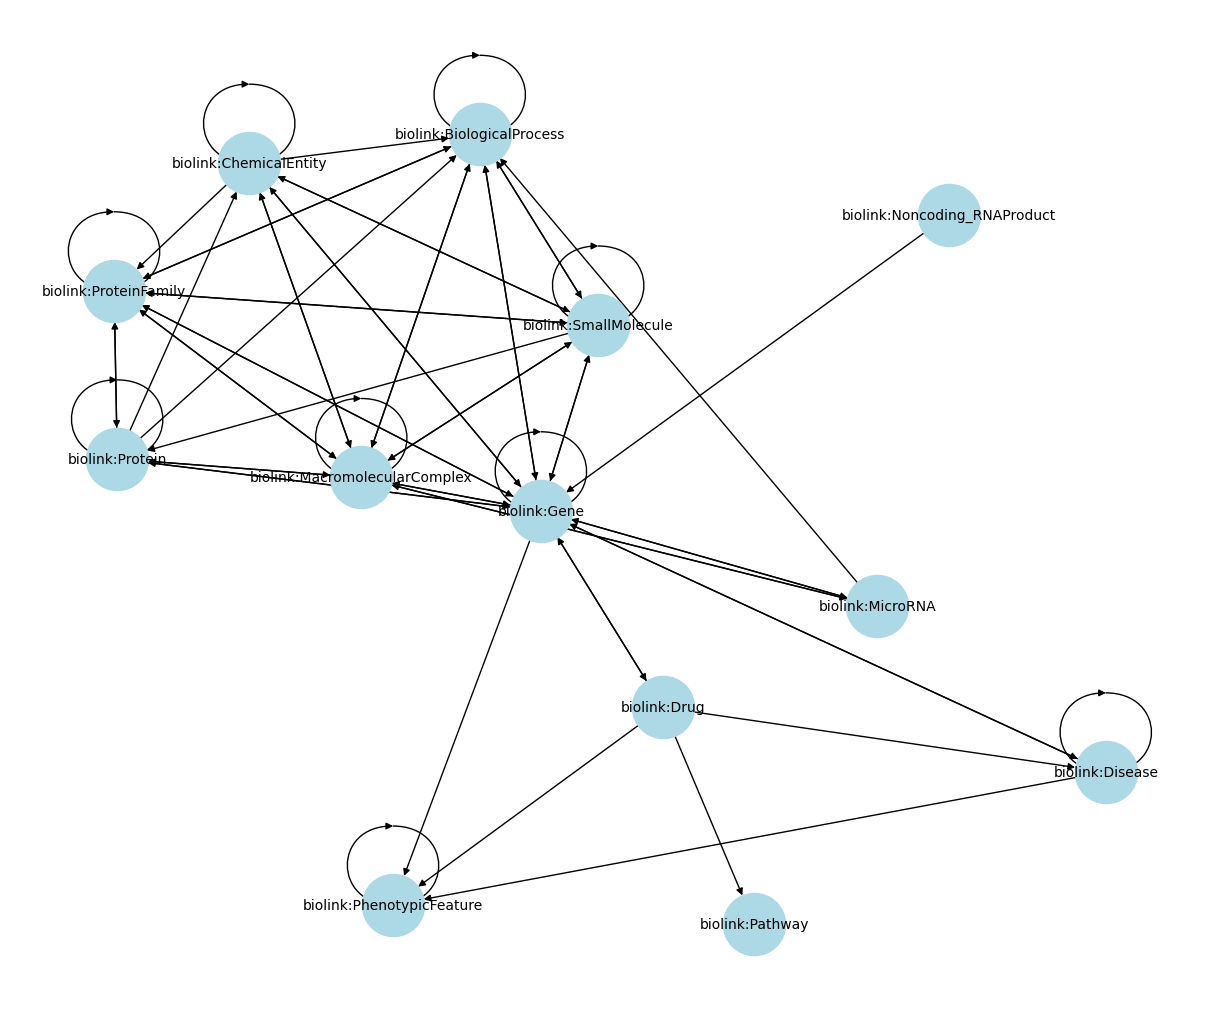

In [24]:
meta_edges_simple = (
    source_edge_df
    .groupby(['subject_category', 'object_category'])
    .agg({'predicate': lambda x: list(set(x))})
    .reset_index()
)

G = nx.DiGraph()

for _, row in meta_edges_simple.iterrows():
    G.add_edge(
        row['subject_category'],
        row['object_category'],
        predicates=row['predicate']
    )

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42, k=1.5)   # more spread out

nx.draw(
    G, pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2000,
    font_size=10,
    arrows=True
)

plt.show()